## Import libraries

## Model Training Toggle and Saving

In [5]:
!pip install kagglehub pandas transformers datasets torch tqdm
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

import re
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm.auto import tqdm
import logging
from collections import Counter

!pip install lime
from lime.lime_text import LimeTextExplainer

logging.getLogger("transformers").setLevel(logging.ERROR)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 22.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=49ac22dfd0638ecfb2b19e89251b9b38639f0572eccc5f16237e48a6a1d90ad9
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [6]:
TRAIN_MODELS = True # Set to False to load pre-trained models
MODELS_DIR = './models'

if not os.path.exists(MODELS_DIR):
    os.makedirs(MODELS_DIR)

## Download and load datas

100%|██████████| 26.5M/26.5M [00:02<00:00, 9.51MB/s]

Extracting files...


Total length of data: 106108


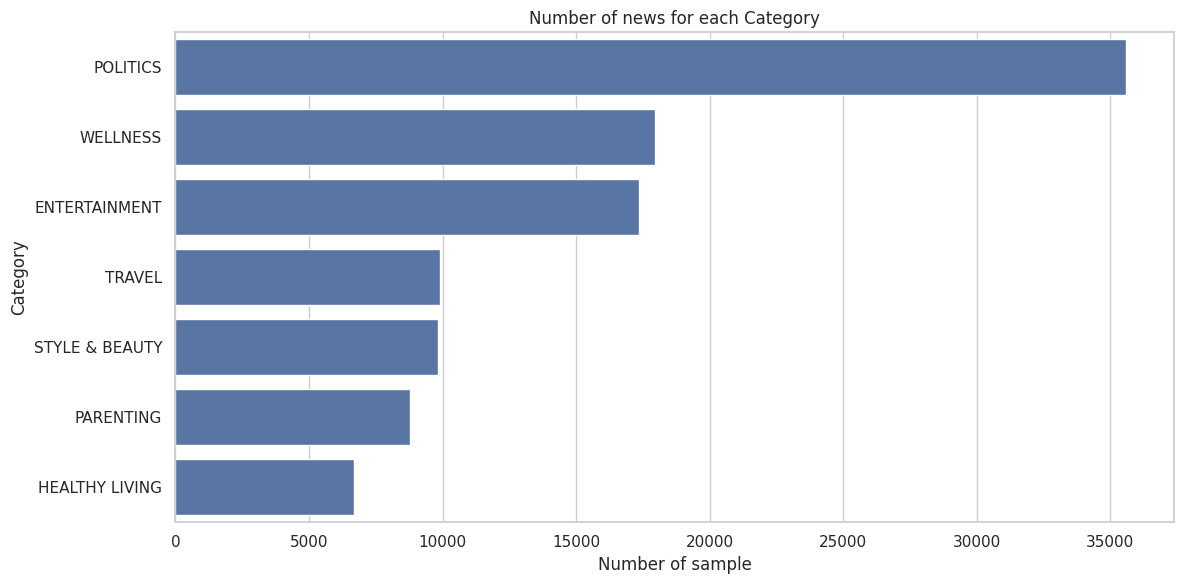

In [7]:
path = kagglehub.dataset_download("rmisra/news-category-dataset")
file_name = "News_Category_Dataset_v3.json"
full_path = os.path.join(path, file_name)

df = pd.read_json(full_path, lines=True)

target_categories = [
    'POLITICS', 'WELLNESS', 'ENTERTAINMENT',
    'TRAVEL', 'STYLE & BEAUTY', 'PARENTING', 'HEALTHY LIVING'
]

df_filtered = df[df['category'].isin(target_categories)]
df = df_filtered[['category', 'headline', 'short_description']].copy()

print(f"Total length of data: {len(df)}")
sns.set(style="whitegrid")

category_counts = df['category'].value_counts().reset_index()
category_counts.columns = ['category', 'count']

plt.figure(figsize=(12, 6))
sns.barplot(data=category_counts, x='count', y='category')

plt.title('Number of news for each Category')
plt.xlabel('Number of sample')
plt.ylabel('Category')
plt.tight_layout()

## Preprocess Data

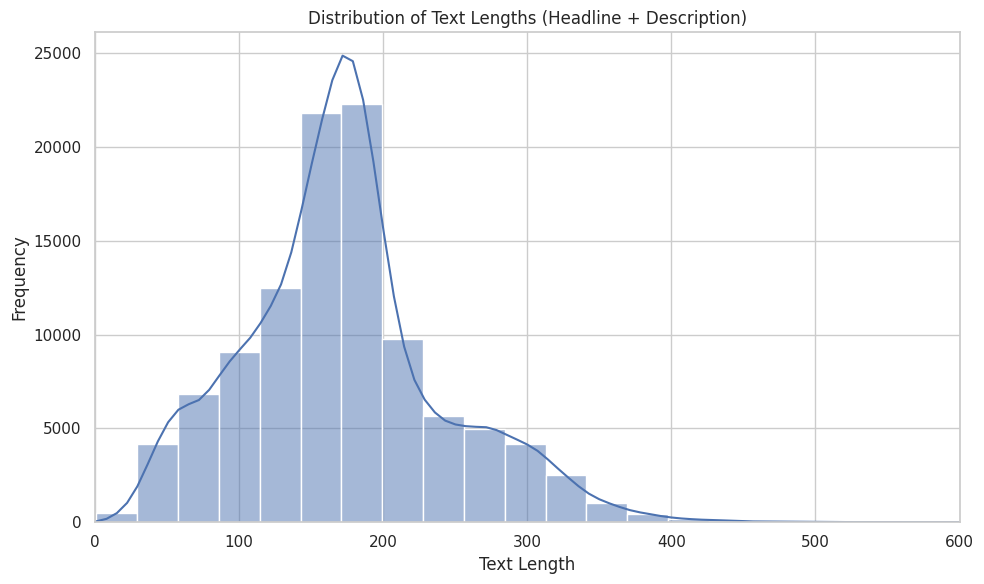

Training set size: 74275
Validation set size: 10611
Testing set size: 21222


In [8]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['headline'] = df['headline'].apply(clean_text)
df['description'] = df['short_description'].apply(clean_text)

df['full_text'] = df['headline'] + ' ' + df['description']
df['text_length'] = df['full_text'].apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(df['text_length'], bins=50, kde=True)
plt.title('Distribution of Text Lengths (Headline + Description)')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.xlim(0, 600)
plt.tight_layout()
plt.show()

df[['category', 'headline', 'description', 'full_text', 'text_length']].head()

train_val_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['category']
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.125,
    random_state=42,
    stratify=train_val_df['category']
)

print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Testing set size: {len(test_df)}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


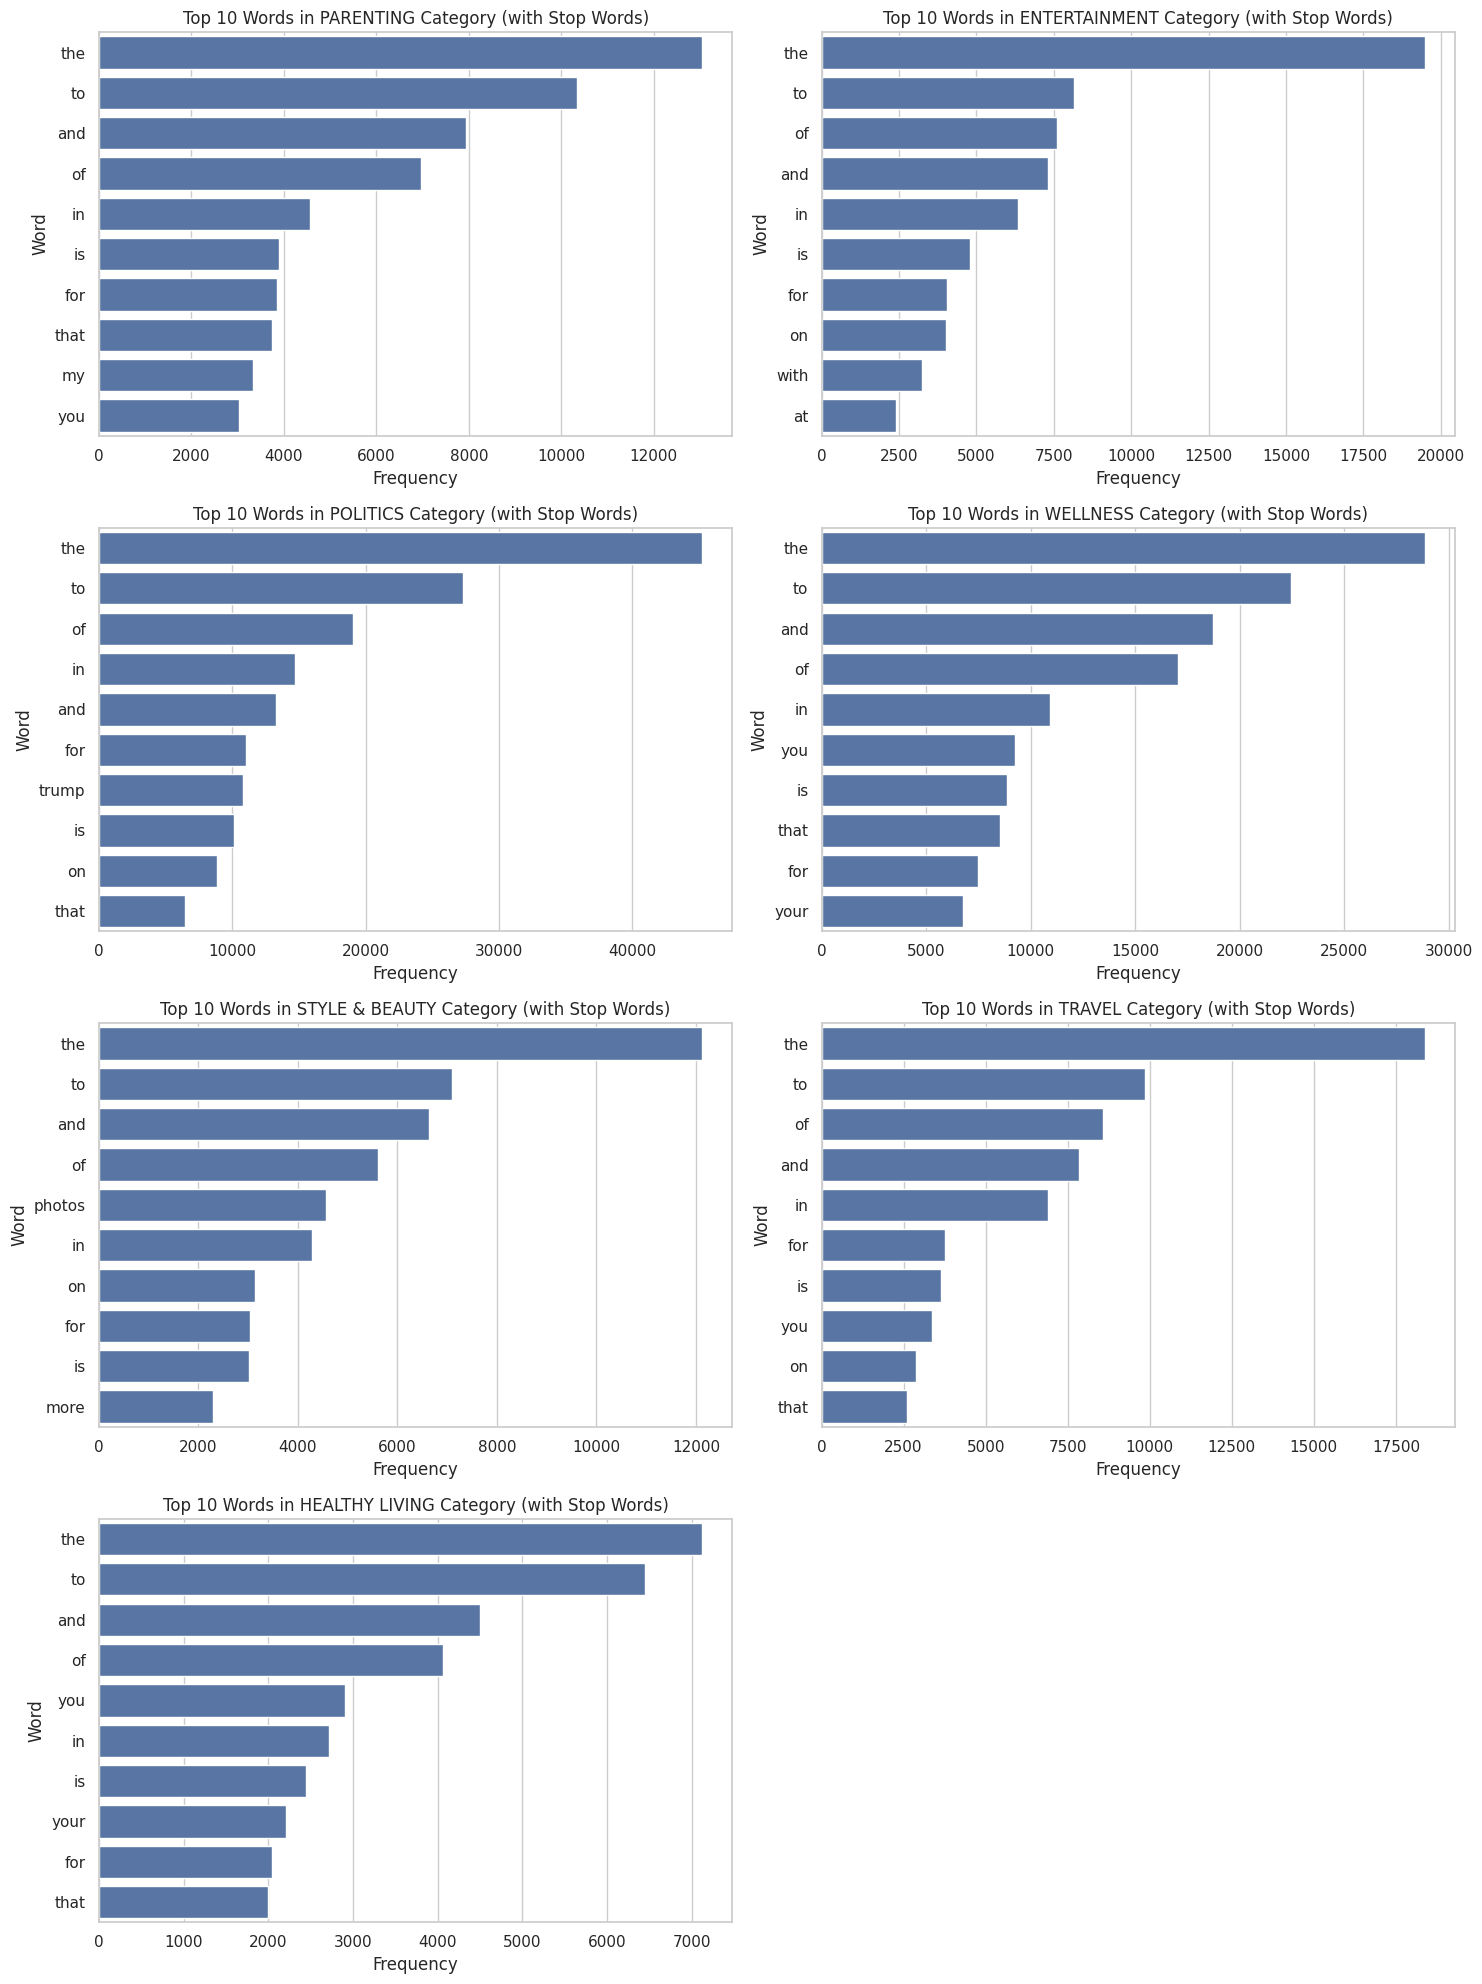

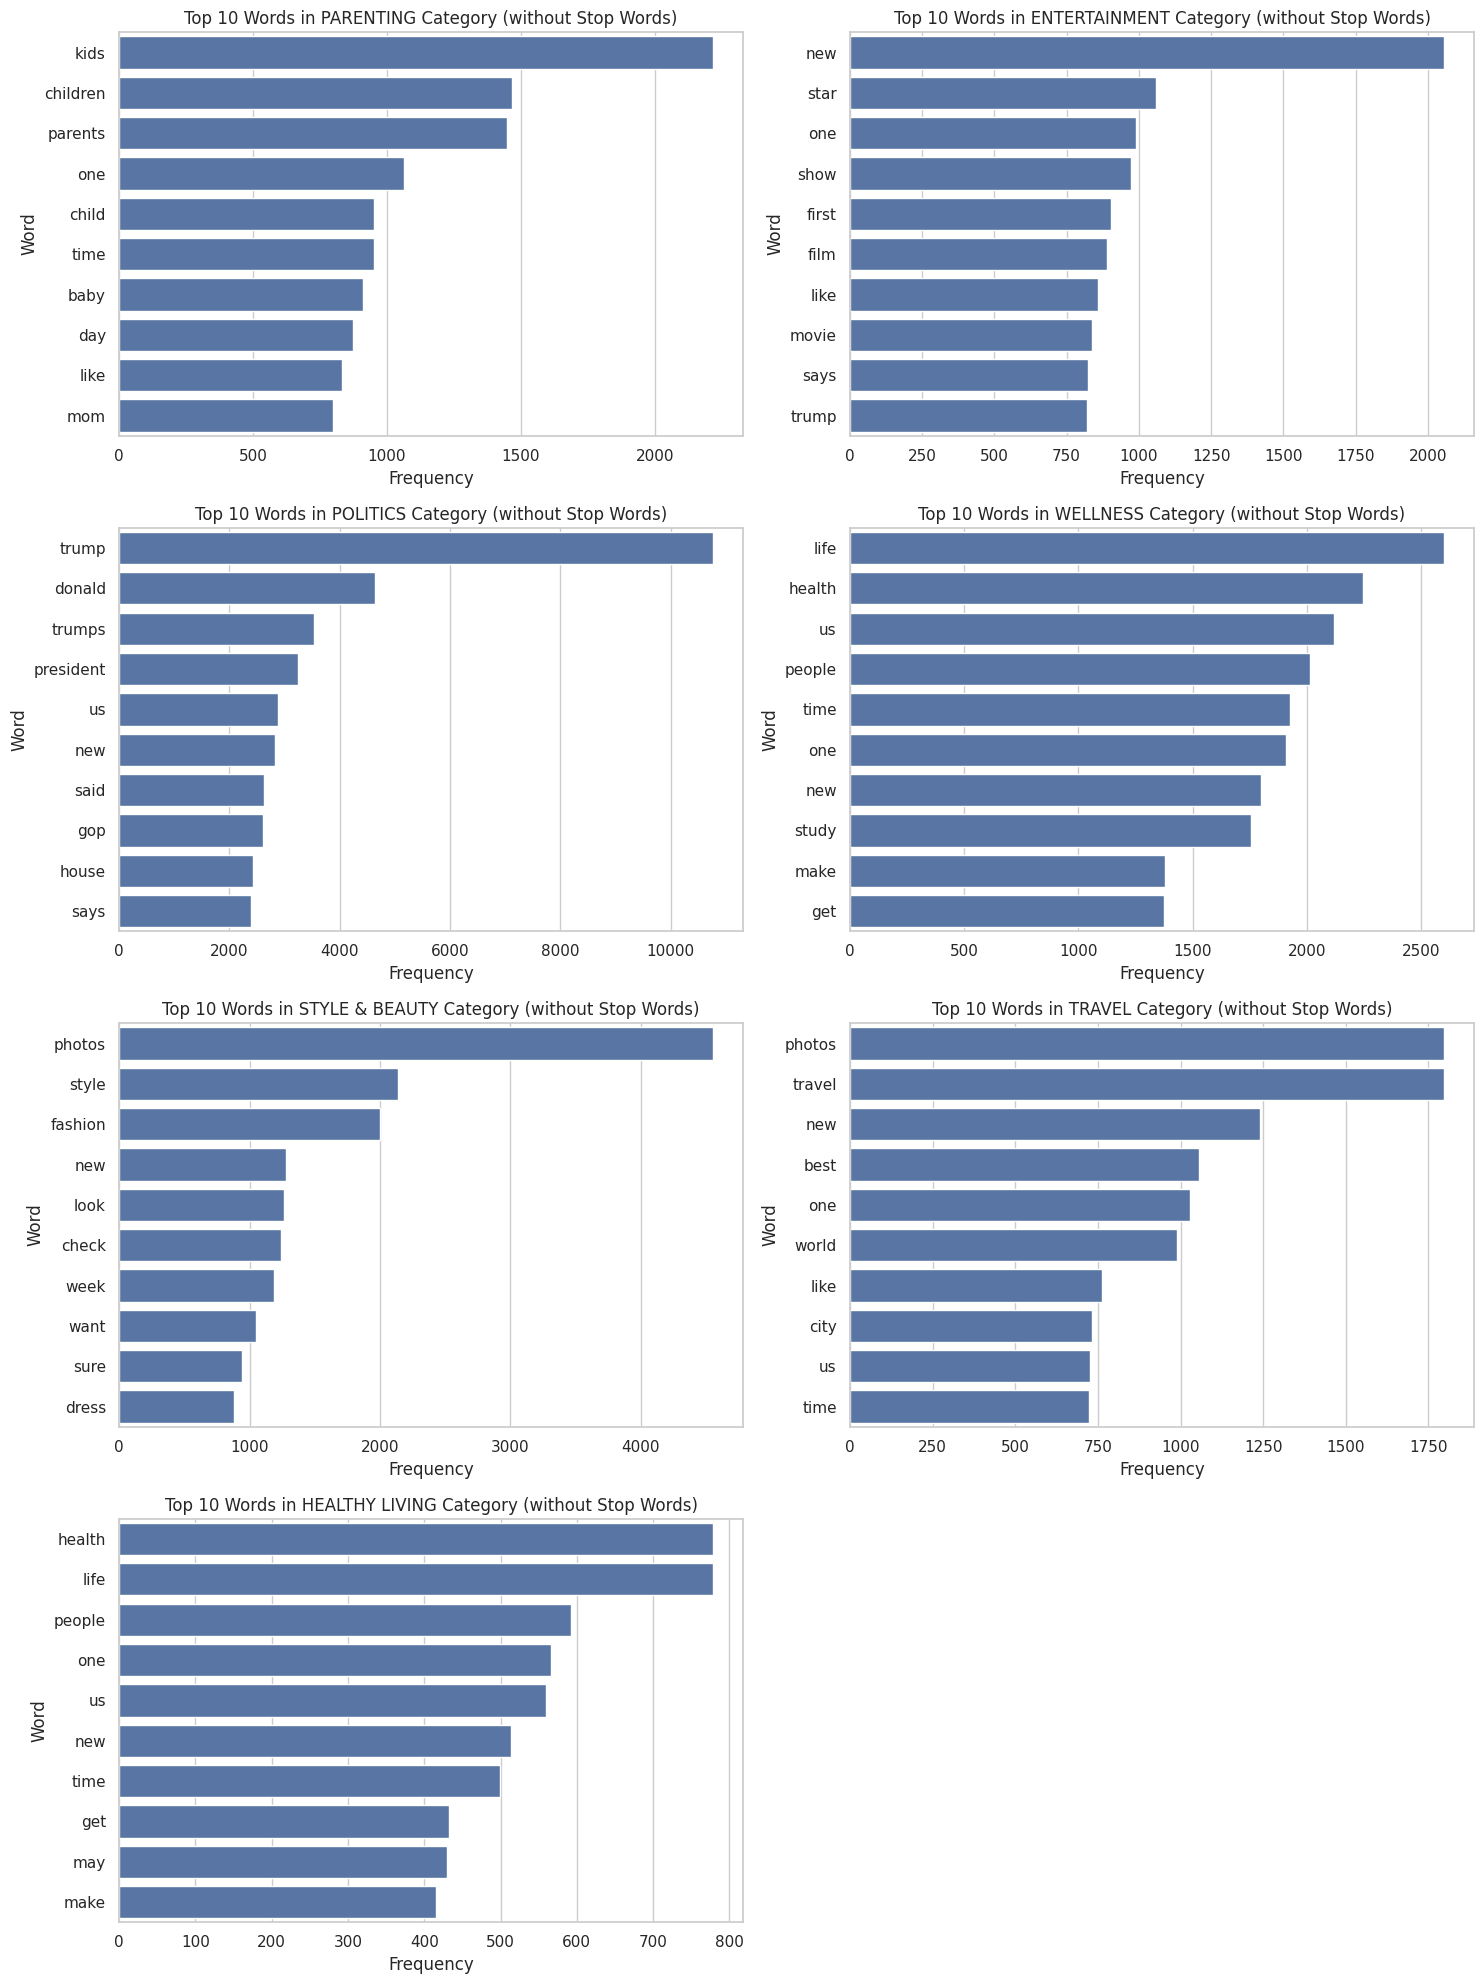

In [9]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def plot_top_words_by_category(dataframe, text_column='full_text', category_column='category', n_top_words=10, include_stopwords=True):
    unique_categories = dataframe[category_column].unique()
    num_categories = len(unique_categories)

    plt.figure(figsize=(15, 5 * ((num_categories + 1) // 2)))

    for i, category in enumerate(unique_categories):
        category_texts = dataframe[dataframe[category_column] == category][text_column]
        all_words = ' '.join(category_texts).split()

        if include_stopwords:
            filtered_words = [word for word in all_words if len(word) > 1]
        else:
            filtered_words = [word for word in all_words if len(word) > 1 and word not in stop_words]

        word_counts = Counter(filtered_words)
        top_words = word_counts.most_common(n_top_words)

        if top_words:
            words, counts = zip(*top_words)
            plt.subplot((num_categories + 1) // 2, 2, i + 1)
            sns.barplot(x=list(counts), y=list(words))
            title_suffix = " (with Stop Words)" if include_stopwords else " (without Stop Words)"
            plt.title(f'Top {n_top_words} Words in {category} Category' + title_suffix)
            plt.xlabel('Frequency')
            plt.ylabel('Word')

    plt.tight_layout()
    plt.show()

plot_top_words_by_category(df, n_top_words=10, include_stopwords=True)

plot_top_words_by_category(df, n_top_words=10, include_stopwords=False)

## Handling imbalanced class

In [10]:
classes = np.unique(df['category'])
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['category']
)

class_weights_dict = dict(zip(range(len(classes)), weights))

category_to_id = {cate: i for i, cate in enumerate(classes)}
train_df['label'] = train_df['category'].map(category_to_id)
val_df['label'] = val_df['category'].map(category_to_id)

## Tokenization

In [11]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

test_df['label'] = test_df['category'].map(category_to_id)

def tokenize_data(texts):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="pt"
    )

X_train = tokenize_data(train_df['full_text'])
y_train = torch.tensor(train_df['label'].values)

X_val = tokenize_data(val_df['full_text'])
y_val = torch.tensor(val_df['label'].values)

X_test = tokenize_data(test_df['full_text'])
y_test = torch.tensor(test_df['label'].values)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## Model Training & Evaluation Setup

In [12]:
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

def train_model(model_name, learning_rate, batch_size, epochs=2):
    current_tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(classes))
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    model_path = os.path.join(MODELS_DIR, f"{model_name}.pth")

    if TRAIN_MODELS:
        train_dataset = NewsDataset(train_df['full_text'].values, train_df['label'].values, current_tokenizer)
        val_dataset = NewsDataset(val_df['full_text'].values, val_df['label'].values, current_tokenizer) # Add validation dataset
        test_dataset = NewsDataset(test_df['full_text'].values, test_df['label'].values, current_tokenizer)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size) # Add validation loader
        test_loader = DataLoader(test_dataset, batch_size=batch_size)

        optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

        start_time = time.time()
        for epoch in range(epochs):
            model.train()
            train_loss = 0
            pbar = tqdm(train_loader, desc=f"{model_name} Epoch {epoch+1}/{epochs} (Training)")
            for batch in pbar:
                optimizer.zero_grad()
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
                pbar.set_postfix({'loss': loss.item()})

            model.eval()
            val_predictions, val_true_labels = [], []
            val_loss = 0
            with torch.no_grad():
                val_pbar = tqdm(val_loader, desc=f"{model_name} Epoch {epoch+1}/{epochs} (Validation)")
                for batch in val_pbar:
                    input_ids = batch['input_ids'].to(device)
                    attention_mask = batch['attention_mask'].to(device)
                    labels = batch['labels'].to(device)
                    outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
                    val_loss += outputs.loss.item()
                    _, preds = torch.max(outputs.logits, dim=1)
                    val_predictions.extend(preds.cpu().numpy())
                    val_true_labels.extend(labels.cpu().numpy())

            val_acc = accuracy_score(val_true_labels, val_predictions)
            print(f"Epoch {epoch+1}: Train Loss: {train_loss/len(train_loader):.4f}, Validation Loss: {val_loss/len(val_loader):.4f}, Validation Accuracy: {val_acc:.4f}")

        training_time = time.time() - start_time

        # Save the trained model
        torch.save(model.state_dict(), model_path)
        print(f"Model '{model_name}' saved to {model_path}")

    else:
        print(f"Loading pre-trained model '{model_name}' from {model_path}")
        model.load_state_dict(torch.load(model_path, map_location=device))
        training_time = 0 # No training, so time is 0

    model.eval()
    test_dataset = NewsDataset(test_df['full_text'].values, test_df['label'].values, current_tokenizer)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    test_predictions, test_true_labels = [], []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f"Evaluating {model_name} on Test Set"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids, attention_mask=attention_mask)
            _, preds = torch.max(outputs.logits, dim=1)
            test_predictions.extend(preds.cpu().numpy())
            test_true_labels.extend(labels.cpu().numpy())

    test_acc = accuracy_score(test_true_labels, test_predictions)
    return {'model_name': model_name, 'accuracy': test_acc, 'time': training_time, 'model': model}

In [13]:
import torch.nn.functional as F

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, text, attention_mask=None):
        embedded = self.embedding(text)
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        return self.fc(hidden)

class CNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, n_filters, filter_sizes, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.convs = nn.ModuleList([
            nn.Conv2d(1, n_filters, (fs, embed_dim)) for fs in filter_sizes
        ])
        self.fc = nn.Linear(len(filter_sizes) * n_filters, output_dim)

    def forward(self, text, attention_mask=None):
        embedded = self.embedding(text).unsqueeze(1)
        conved = [F.relu(conv(embedded)).squeeze(3) for conv in self.convs]
        pooled = [F.max_pool1d(conv, conv.shape[2]).squeeze(2) for conv in conved]
        cat = torch.cat(pooled, dim=1)
        return self.fc(cat)

class RCNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2 + embed_dim, output_dim)

    def forward(self, text, attention_mask=None):
        embedded = self.embedding(text)
        out, _ = self.lstm(embedded)
        out = torch.cat((out, embedded), dim=2)
        out = F.relu(out)
        out = out.permute(0, 2, 1)
        out = F.max_pool1d(out, out.shape[2]).squeeze(2)
        return self.fc(out)

In [14]:
def train_custom_model(model, model_name, learning_rate, batch_size, epochs=5):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    model_path = os.path.join(MODELS_DIR, f"{model_name}.pth")

    if TRAIN_MODELS:
        train_dataset = NewsDataset(train_df['full_text'].values, train_df['label'].values, tokenizer)
        val_dataset = NewsDataset(val_df['full_text'].values, val_df['label'].values, tokenizer)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)

        start_time = time.time()
        for epoch in range(epochs):
            model.train()
            train_loss = 0
            pbar = tqdm(train_loader, desc=f"{model_name} Epoch {epoch+1}/{epochs} (Training)")
            for batch in pbar:
                optimizer.zero_grad()
                input_ids = batch['input_ids'].to(device)
                labels = batch['labels'].to(device)
                outputs = model(input_ids)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
                pbar.set_postfix({'loss': loss.item()})

            model.eval()
            val_predictions, val_true_labels = [], []
            val_loss = 0
            with torch.no_grad():
                val_pbar = tqdm(val_loader, desc=f"{model_name} Epoch {epoch+1}/{epochs} (Validation)")
                for batch in val_pbar:
                    input_ids = batch['input_ids'].to(device)
                    labels = batch['labels'].to(device)
                    outputs = model(input_ids)
                    val_loss += criterion(outputs, labels).item()
                    _, preds = torch.max(outputs, 1)
                    val_predictions.extend(preds.cpu().numpy())
                    val_true_labels.extend(labels.cpu().numpy())

            val_acc = accuracy_score(val_true_labels, val_predictions)
            print(f"Epoch {epoch+1}: Train Loss: {train_loss/len(train_loader):.4f}, Validation Loss: {val_loss/len(val_loader):.4f}, Validation Accuracy: {val_acc:.4f}")

        training_time = time.time() - start_time

        # Save the trained model
        torch.save(model.state_dict(), model_path)
        print(f"Model '{model_name}' saved to {model_path}")
    else:
        print(f"Loading pre-trained model '{model_name}' from {model_path}")
        model.load_state_dict(torch.load(model_path, map_location=device))
        training_time = 0 # No training, so time is 0

    model.eval()
    test_dataset = NewsDataset(test_df['full_text'].values, test_df['label'].values, tokenizer)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    test_preds, test_actuals = [], []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f"Evaluating {model_name} on Test Set"):
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids)
            _, p = torch.max(outputs, 1)
            test_preds.extend(p.cpu().numpy())
            test_actuals.extend(labels.cpu().numpy())

    test_acc = accuracy_score(test_actuals, test_preds)
    return {'model_name': model_name, 'accuracy': test_acc, 'time': training_time, 'model': model}

## Train Models with Different Parameters

In [ ]:
results = []
trained_models = {}

vocab_size = tokenizer.vocab_size

# lstm_output = train_custom_model(LSTMModel(vocab_size, 100, 128, len(classes)), 'LSTM', 1e-3, 32)
# trained_models['LSTM'] = lstm_output['model']
# del lstm_output['model']
# results.append(lstm_output)

# cnn_output = train_custom_model(CNNModel(vocab_size, 100, 100, [3, 4, 5], len(classes)), 'CNN', 1e-3, 32)
# trained_models['CNN'] = cnn_output['model']
# del cnn_output['model']
# results.append(cnn_output)

# rcnn_output = train_custom_model(RCNNModel(vocab_size, 100, 128, len(classes)), 'RCNN', 1e-3, 32)
# trained_models['RCNN'] = rcnn_output['model']
# del rcnn_output['model']
# results.append(rcnn_output)

# distilbert_output = train_model('distilbert-base-uncased', 2e-5, 16)
# trained_models['distilbert-base-uncased'] = distilbert_output['model']
# del distilbert_output['model']
# results.append(distilbert_output)

roberta_output = train_model('roberta-base', 2e-5, 16)
trained_models['roberta-base'] = roberta_output['model']
del roberta_output['model']
results.append(roberta_output)

albert_output = train_model('albert-base-v2', 2e-5, 16)
trained_models['albert-base-v2'] = albert_output['model']
del albert_output['model']
results.append(albert_output)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

roberta-base Epoch 1/2 (Training):   0%|          | 0/4643 [00:00<?, ?it/s]

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def get_predictions(model_instance, model_name_for_tokenizer, is_custom=False):
    if is_custom:
        current_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
    else:
        current_tokenizer = AutoTokenizer.from_pretrained(model_name_for_tokenizer)

    model_instance.eval()
    test_dataset = NewsDataset(test_df['full_text'].values, test_df['label'].values, current_tokenizer)
    test_loader = DataLoader(test_dataset, batch_size=32)

    preds, actuals = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            if not is_custom:
                attention_mask = batch['attention_mask'].to(device)
                outputs = model_instance(input_ids, attention_mask=attention_mask)
                logits = outputs.logits
            else:
                logits = model_instance(input_ids)
            _, p = torch.max(logits, 1)
            preds.extend(p.cpu().numpy())
            actuals.extend(labels.cpu().numpy())
    return preds, actuals

In [17]:
def get_ensemble_predictions(models, model_names, test_df, category_to_id, classes):
    all_predictions = []
    for model_name in model_names:
        model_instance = models[model_name]
        is_custom = model_name not in ['distilbert-base-uncased', 'roberta-base', 'albert-base-v2']
        preds, _ = get_predictions(model_instance, model_name, is_custom)
        all_predictions.append(preds)

    all_predictions = np.array(all_predictions).T

    ensemble_preds = []
    for sample_preds in all_predictions:
        most_common = Counter(sample_preds).most_common(1)
        ensemble_preds.append(most_common[0][0])

    return ensemble_preds


--- Individual Model Analysis ---

--- Analysis for Model: LSTM ---
Classification Report for LSTM:
                precision    recall  f1-score   support

 ENTERTAINMENT       0.87      0.82      0.84      3472
HEALTHY LIVING       0.64      0.45      0.53      1339
     PARENTING       0.74      0.82      0.78      1758
      POLITICS       0.90      0.94      0.92      7121
STYLE & BEAUTY       0.91      0.82      0.86      1963
        TRAVEL       0.81      0.83      0.82      1980
      WELLNESS       0.76      0.83      0.79      3589

      accuracy                           0.84     21222
     macro avg       0.81      0.78      0.79     21222
  weighted avg       0.84      0.84      0.84     21222



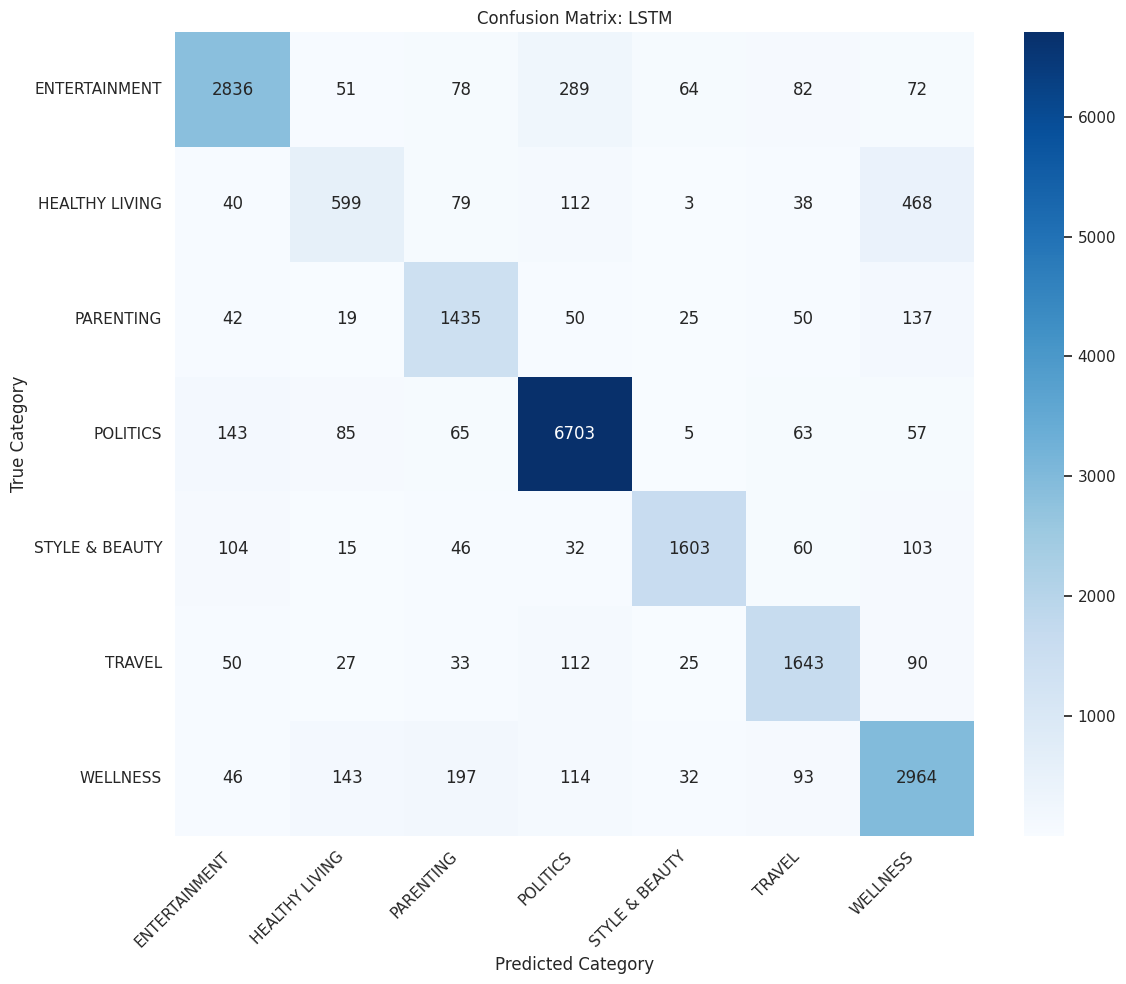

Total errors for LSTM: 3439
5 Sample Misclassified Examples for LSTM:
  Text: history now made the us and cuba face a bumpy road ahead 
  True Category: POLITICS
  Predicted Category: ENTERTAINMENT
------------------------------
  Text: tricks from mom to help you manage stress every mother knows what it is to feel out of energy and patience but a mother never runs out of love its selfreplenishing this week treat yourself to that same patience and support the kind you have shown to your own friends and family to help you ease the negative effects of stress
  True Category: HEALTHY LIVING
  Predicted Category: WELLNESS
------------------------------
  Text: best of venice with tsili amos gitai explains survival in a desperate universe among the greatest of teachers i personally hold amos gitai in a top position his work such as his latest masterpiece tsili is insightful groundbreaking thoughtprovoking strong full of emotions and always entertaining the best example of cinema with a cons

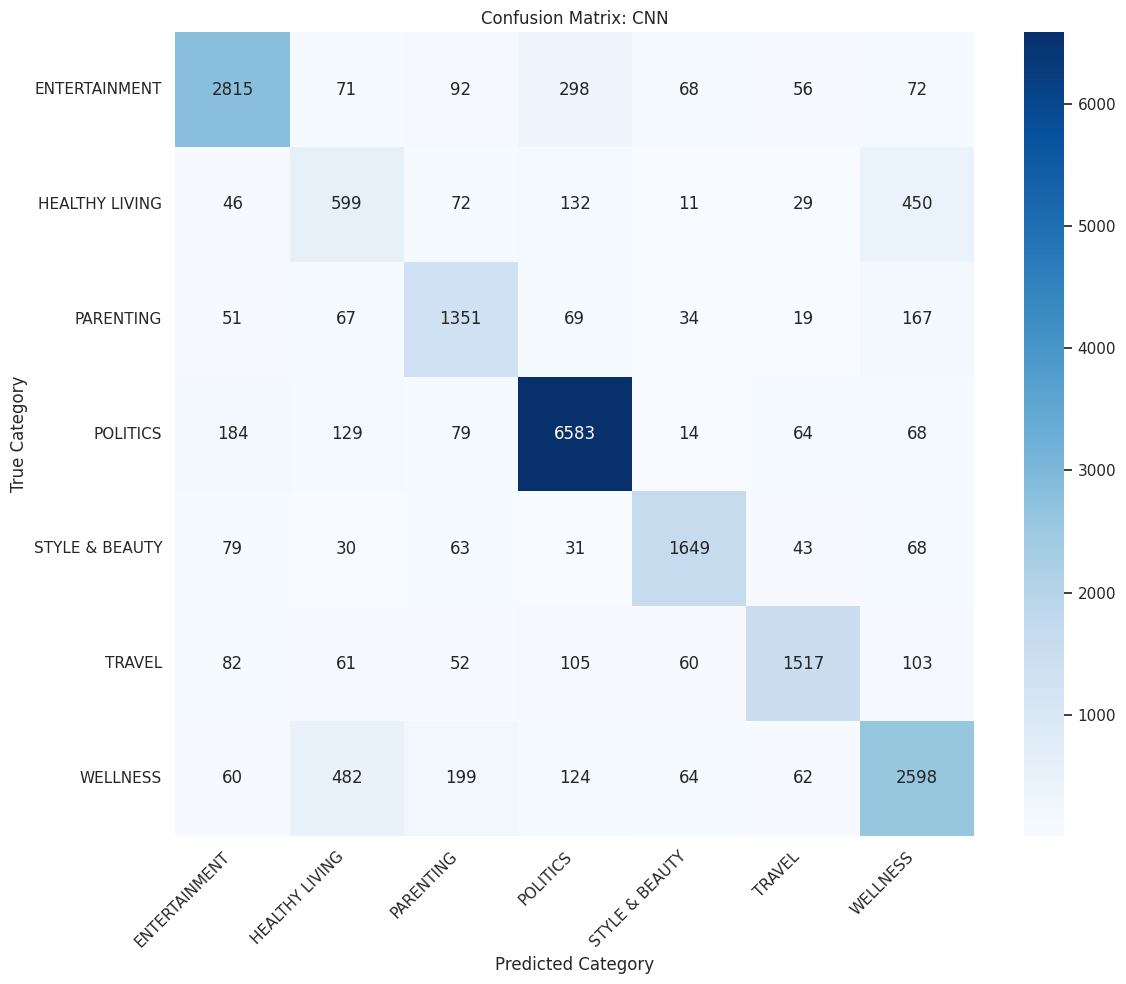

Total errors for CNN: 4110
5 Sample Misclassified Examples for CNN:
  Text: next royal milestone september years ago on june th at the age of years months and days william iv became king upon the death of his older brother george iv william iv is probably best known for being the uncle and predecessor of queen victoria
  True Category: STYLE & BEAUTY
  Predicted Category: WELLNESS
------------------------------
  Text: the best stretches for bike riders you have to give your body the attention it needs postbiking so that it can perform at its best try these four stretches before and after your next ride and youll hopefully find your legs neck and hips feeling looser and less sore
  True Category: HEALTHY LIVING
  Predicted Category: WELLNESS
------------------------------
  Text: so how was your weekend after spending a weekend not writing about politics you just know whats bursting at the seams after all so much has already
  True Category: POLITICS
  Predicted Category: HEALTHY LIVIN

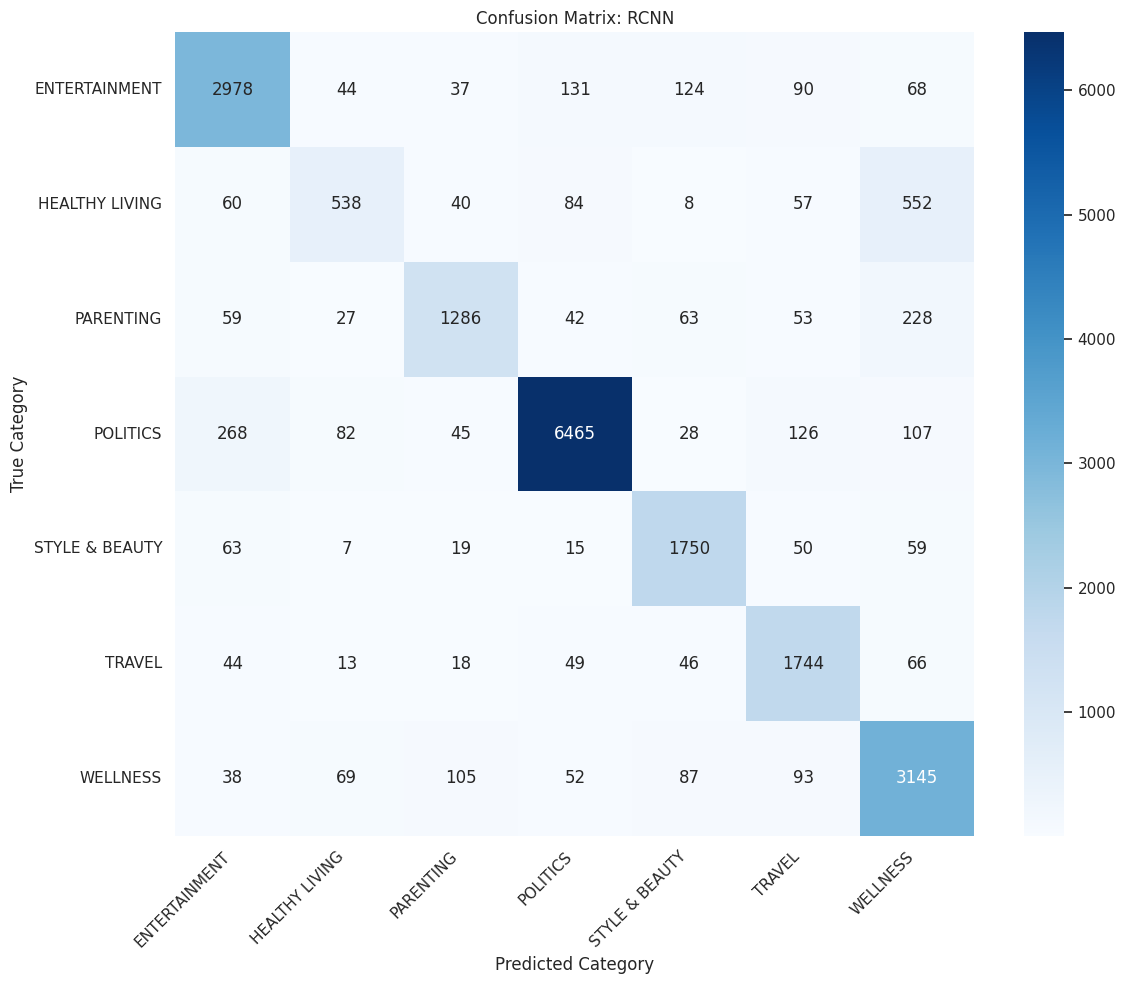

Total errors for RCNN: 3316
5 Sample Misclassified Examples for RCNN:
  Text: china is made for ecommerce 
  True Category: POLITICS
  Predicted Category: ENTERTAINMENT
------------------------------
  Text: diverse childrens cartoons where the main character isnt necessarily white stereotypes run rampant in much of our media consumption and childrens cartoons are no exception our children no matter what their race or background dont see enough cartoons with diverse characters in different cultural settings
  True Category: PARENTING
  Predicted Category: ENTERTAINMENT
------------------------------
  Text: moving to china why a little crazy is a good thing a year ago i was writing my senior thesis for my ba and could never have guessed id be teaching english in china in just one year several people have called me brave but im not brave i just took a professors advice seriously go teach in china he said so i did
  True Category: TRAVEL
  Predicted Category: PARENTING
------------------

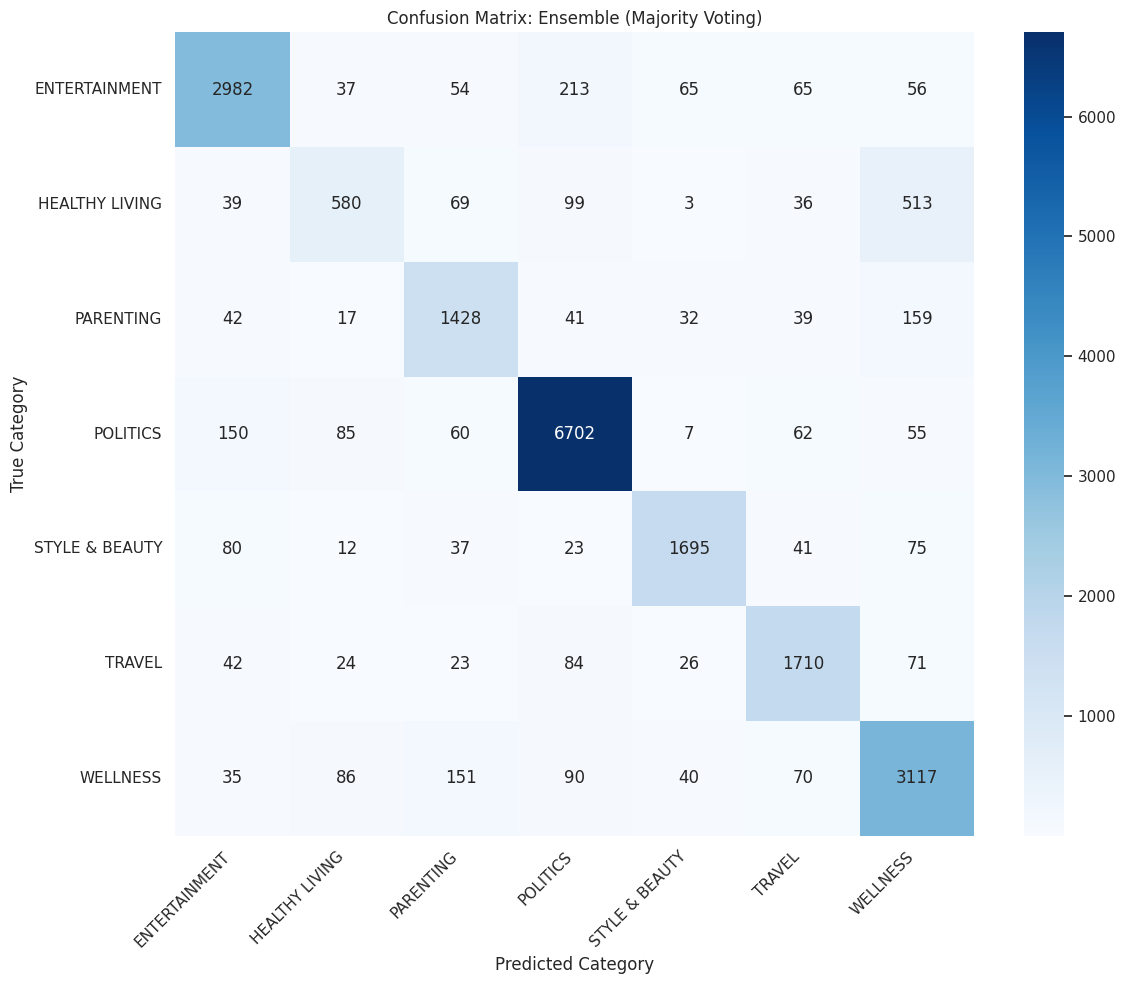

Total errors for Ensemble: 3008
5 Sample Misclassified Examples for Ensemble:
  Text: a season of miracles december has always been a miraculous time it marks the season in my life when i labored with both my children on the same date in different years december but i cannot help but think of a community not so very far from my own december marks a very different day for them
  True Category: PARENTING
  Predicted Category: WELLNESS
------------------------------
  Text: i remember papa jonathan winters smurfy swan song when it came time to find just the right voice for papa smurf raja gosnell and jordan kerner were admittedly feeling a little blue why for because the casting department at sony pictures animation kept coming up short
  True Category: ENTERTAINMENT
  Predicted Category: STYLE & BEAUTY
------------------------------
  Text: new project seeks to unmask shadowy payday lenders everyone knows what payday lenders do but very few people know who the payday lenders actually are

,model_name,accuracy,time
0,LSTM,0.837951,467.923564
1,CNN,0.806333,1312.441355
2,RCNN,0.843747,471.801298
3,Ensemble (Majority Voting),0.858260,0.000000


In [18]:
print("\n--- Individual Model Analysis ---")
for model_name, model_instance in trained_models.items():
    print(f"\n--- Analysis for Model: {model_name} ---")

    # Determine if it's a custom model for tokenizer loading
    is_custom = model_name not in ['distilbert-base-uncased', 'roberta-base', 'albert-base-v2']
    y_pred, y_true = get_predictions(model_instance, model_name, is_custom=is_custom)

    # Classification Report
    print(f"Classification Report for {model_name}:")
    print(classification_report(y_true, y_pred, target_names=classes))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes
    )
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted Category')
    plt.ylabel('True Category')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Error Analysis
    error_df = test_df.copy()
    error_df['predicted_label_id'] = y_pred
    error_df['predicted'] = [classes[p] for p in y_pred]
    errors = error_df[error_df['category'] != error_df['predicted']]

    print(f"Total errors for {model_name}: {len(errors)}")
    if not errors.empty:
        print(f"5 Sample Misclassified Examples for {model_name}:")
        # Iterate and print misclassified text
        for idx, row in errors.sample(min(5, len(errors))).iterrows():
            print(f"  Text: {row['full_text']}")
            print(f"  True Category: {row['category']}")
            print(f"  Predicted Category: {row['predicted']}")
            print("-" * 30)
    else:
        print(f"No errors found for {model_name}.")

# --- Ensemble Model Analysis ---
print("\n--- Ensemble Model Analysis (Majority Voting) ---")
model_names = list(trained_models.keys())
ensemble_y_pred = get_ensemble_predictions(trained_models, model_names, test_df, category_to_id, classes)
ensemble_y_true = test_df['label'].values

ensemble_accuracy = accuracy_score(ensemble_y_true, ensemble_y_pred)

print(f"Ensemble Model Accuracy: {ensemble_accuracy:.4f}")
print(classification_report(ensemble_y_true, ensemble_y_pred, target_names=classes))

ensemble_result = {
    'model_name': 'Ensemble (Majority Voting)',
    'accuracy': ensemble_accuracy,
    'time': 0
}
results.append(ensemble_result)

# Confusion Matrix for Ensemble
cm_ensemble = confusion_matrix(ensemble_y_true, ensemble_y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_ensemble,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)
plt.title('Confusion Matrix: Ensemble (Majority Voting)')
plt.xlabel('Predicted Category')
plt.ylabel('True Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Error Analysis for Ensemble
ensemble_error_df = test_df.copy()
ensemble_error_df['predicted_label_id'] = ensemble_y_pred
ensemble_error_df['predicted'] = [classes[p] for p in ensemble_y_pred]
ensemble_errors = ensemble_error_df[ensemble_error_df['category'] != ensemble_error_df['predicted']]

print(f"Total errors for Ensemble: {len(ensemble_errors)}")
if not ensemble_errors.empty:
    print("5 Sample Misclassified Examples for Ensemble:")
    # Iterate and print misclassified text
    for idx, row in ensemble_errors.sample(min(5, len(ensemble_errors))).iterrows():
        print(f"  Text: {row['full_text']}")
        print(f"  True Category: {row['category']}")
        print(f"  Predicted Category: {row['predicted']}")
        print("-" * 30)
else:
    print("No errors found for Ensemble.")

stats_df = pd.DataFrame(results)
print("\n--- All Model Statistics ---")
display(stats_df)

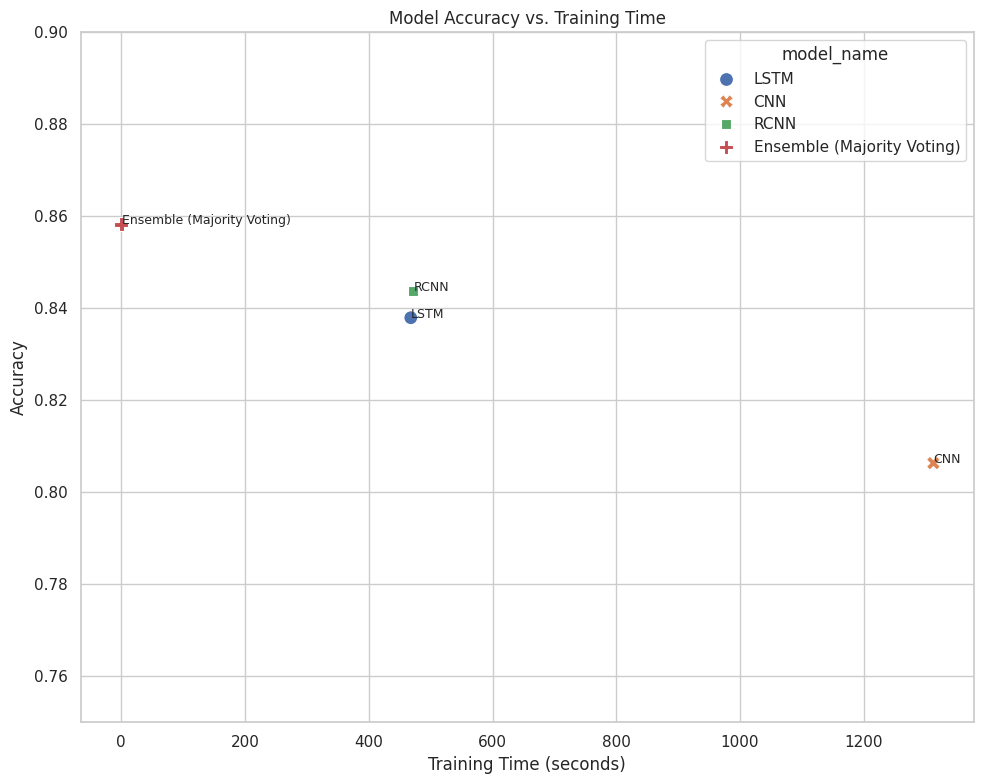

In [19]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='time', y='accuracy', hue='model_name', data=stats_df, s=100, style='model_name')

for i, row in stats_df.iterrows():
    plt.text(row['time'] + 0.5, row['accuracy'], row['model_name'], fontsize=9)

plt.title('Model Accuracy vs. Training Time')
plt.xlabel('Training Time (seconds)')
plt.ylabel('Accuracy')
plt.ylim(0.75, 0.9)
plt.grid(True)
plt.tight_layout()
plt.show()